# Jawablah poin-poin assignment berikut
#### perhatikan dengan baik apa yang diminta pada soal

#### Notes : Tidak perlu melakukan sampling data (random sampling data)

# 1. Anda bekerja sebagai seorang data scientist, atasan anda mengirimkan anda data kepada anda dan meminta untuk memberikan analisa dengan menggunakan :
- semua metode pada proses Exploratory Data Analysis. Lakukan proses Feature Engineering terlebih dahulu dan mengecek secara teliti pada tiap kolom data sembari melakukan data understanding. **(20 Poin)**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = 'https://raw.githubusercontent.com/mfarhanshiddiq/Dataset/main/ecommerce.csv'
df_ecommerce = pd.read_csv(url)

df_ecommerce.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,554697,21166,COOK WITH WINE METAL SIGN,1,5/25/2011 17:31,2.08,14584,United Kingdom
1,561038,82482,WOODEN PICTURE FRAME WHITE FINISH,2,7/24/2011 11:58,2.55,17114,United Kingdom
2,560552,23192,BUNDLE OF 3 ALPHABET EXERCISE BOOKS,1,7/19/2011 12:54,1.65,15311,United Kingdom
3,559884,85183B,CHARLIE & LOLA WASTEPAPER BIN FLORA,12,7/13/2011 11:34,1.25,16843,United Kingdom
4,544450,21789,KIDS RAIN MAC PINK,3,2/20/2011 12:23,0.85,17811,United Kingdom


**1. Feature Engineering**

a. Handling Duplicate

In [ ]:
df_ecommerce.shape

(4870, 8)

Dataset memiliki 4870 baris dan 8 kolom yang berisi data transaksi pelanggan.

In [ ]:
df_ecommerce.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4870 entries, 0 to 4869
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    4870 non-null   int64  
 1   StockCode    4870 non-null   object 
 2   Description  4870 non-null   object 
 3   Quantity     4870 non-null   int64  
 4   InvoiceDate  4870 non-null   object 
 5   UnitPrice    4870 non-null   float64
 6   CustomerID   4870 non-null   int64  
 7   Country      4870 non-null   object 
dtypes: float64(1), int64(3), object(4)
memory usage: 304.5+ KB


In [ ]:
len(df_ecommerce.drop_duplicates()) / len(df_ecommerce) #type: ignore
#jika output dari code di cell ini tidak bernilai 1 maka terdapat duplikat

1.0

Dari hasil handling duplicate di atas mendapat 1.0 = 100% data unik, dapat diartikan bahwa pada df_ecommerce tidak memiliki data duplicate

b. Change Data Type

In [ ]:
df_ecommerce.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4870 entries, 0 to 4869
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    4870 non-null   int64  
 1   StockCode    4870 non-null   object 
 2   Description  4870 non-null   object 
 3   Quantity     4870 non-null   int64  
 4   InvoiceDate  4870 non-null   object 
 5   UnitPrice    4870 non-null   float64
 6   CustomerID   4870 non-null   int64  
 7   Country      4870 non-null   object 
dtypes: float64(1), int64(3), object(4)
memory usage: 304.5+ KB


In [ ]:
# Mengubah kolom InvoiceDate menjadi tipe data datetime
df_ecommerce['InvoiceDate'] = pd.to_datetime(df_ecommerce['InvoiceDate'])

In [ ]:
df_ecommerce.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4870 entries, 0 to 4869
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    4870 non-null   int64         
 1   StockCode    4870 non-null   object        
 2   Description  4870 non-null   object        
 3   Quantity     4870 non-null   int64         
 4   InvoiceDate  4870 non-null   datetime64[ns]
 5   UnitPrice    4870 non-null   float64       
 6   CustomerID   4870 non-null   int64         
 7   Country      4870 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(3)
memory usage: 304.5+ KB


Pada kolom InvoiceDate sudah bertype data "datetime64[ns]"

Membuat Fitur Waktu

In [ ]:
df_ecommerce['Year'] = df_ecommerce['InvoiceDate'].dt.year
df_ecommerce['Month'] = df_ecommerce['InvoiceDate'].dt.month
df_ecommerce['Day'] = df_ecommerce['InvoiceDate'].dt.day
df_ecommerce['Hour'] = df_ecommerce['InvoiceDate'].dt.hour
df_ecommerce['DayOfWeek'] = df_ecommerce['InvoiceDate'].dt.day_name()

Customer Transaction Count

In [ ]:
df_ecommerce['CustomerTransaction'] = df_ecommerce.groupby('CustomerID')['InvoiceNo'].transform('nunique')

Filter Price

In [ ]:
df_ecommerce = df_ecommerce[df_ecommerce['UnitPrice'] > 0]

c. Missing value Checking and Handling

In [ ]:
df_ecommerce.isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0
Year,0
Month,0


In [ ]:
for col in df_ecommerce.columns:
    print(f"===={col}====")
    print(df_ecommerce[col].value_counts())
    display()

====InvoiceNo====
InvoiceNo
562046    8
575491    7
576339    7
578270    7
559552    6
         ..
573909    1
545996    1
572675    1
540458    1
574289    1
Name: count, Length: 3804, dtype: int64
====StockCode====
StockCode
85099B    24
47566     22
22423     21
85123A    19
22197     18
          ..
22215      1
22521      1
22400      1
23079      1
21849      1
Name: count, Length: 1773, dtype: int64
====Description====
Description
JUMBO BAG RED RETROSPOT               24
PARTY BUNTING                         22
REGENCY CAKESTAND 3 TIER              21
WHITE HANGING HEART T-LIGHT HOLDER    19
60 TEATIME FAIRY CAKE CASES           18
                                      ..
TOADSTOOL BEDSIDE LIGHT                1
SILVER DIAMANTE PEN IN GIFT BOX        1
SWEETHEART WIRE FRUIT BOWL             1
WALL ART CLASSIC PUDDINGS              1
DECORATIVE PLANT POT WITH FRIEZE       1
Name: count, Length: 1807, dtype: int64
====Quantity====
Quantity
1      930
12     705
2      678
4      

Tidak terdapat missing value pada df_ecommerce

d. Outlier Handling

In [ ]:
df_ecommerce.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4870 entries, 0 to 4869
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   InvoiceNo            4870 non-null   int64         
 1   StockCode            4870 non-null   object        
 2   Description          4870 non-null   object        
 3   Quantity             4870 non-null   int64         
 4   InvoiceDate          4870 non-null   datetime64[ns]
 5   UnitPrice            4870 non-null   float64       
 6   CustomerID           4870 non-null   int64         
 7   Country              4870 non-null   object        
 8   Year                 4870 non-null   int32         
 9   Month                4870 non-null   int32         
 10  Day                  4870 non-null   int32         
 11  Hour                 4870 non-null   int32         
 12  DayOfWeek            4870 non-null   object        
 13  CustomerTransaction  4870 non-nul

In [ ]:
Q1 = df_ecommerce['UnitPrice'].quantile(0.25)
Q3 = df_ecommerce['UnitPrice'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound, upper_bound)

-2.5 7.5


In [ ]:
outlier = df_ecommerce[(df_ecommerce['UnitPrice'] < lower_bound) | (df_ecommerce['UnitPrice'] > upper_bound)]
outlier

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Year,Month,Day,Hour,DayOfWeek,CustomerTransaction
9,562888,22485,SET OF 2 WOODEN MARKET CRATES,2,2011-08-10 11:58:00,12.75,14388,United Kingdom,2011,8,10,11,Wednesday,3
11,551983,22485,SET OF 2 WOODEN MARKET CRATES,2,2011-05-05 14:32:00,12.75,17735,United Kingdom,2011,5,5,14,Thursday,8
35,559109,22844,VINTAGE CREAM DOG FOOD CONTAINER,1,2011-07-06 11:52:00,8.50,15021,United Kingdom,2011,7,6,11,Wednesday,7
43,543911,48138,DOORMAT UNION FLAG,2,2011-02-14 12:46:00,7.95,17829,United Arab Emirates,2011,2,14,12,Monday,1
55,569524,48188,DOORMAT WELCOME PUPPIES,2,2011-10-04 14:42:00,8.25,14506,United Kingdom,2011,10,4,14,Tuesday,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4831,548319,21843,RED RETROSPOT CAKE STAND,1,2011-03-30 12:48:00,10.95,14180,United Kingdom,2011,3,30,12,Wednesday,3
4833,579091,22423,REGENCY CAKESTAND 3 TIER,1,2011-11-28 10:49:00,12.75,14893,United Kingdom,2011,11,28,10,Monday,2
4842,576051,21217,RED RETROSPOT ROUND CAKE TINS,6,2011-11-13 14:45:00,9.95,14911,EIRE,2011,11,13,14,Sunday,59
4848,579501,22947,WOODEN ADVENT CALENDAR RED,5,2011-11-29 16:16:00,7.95,14088,United Kingdom,2011,11,29,16,Tuesday,8


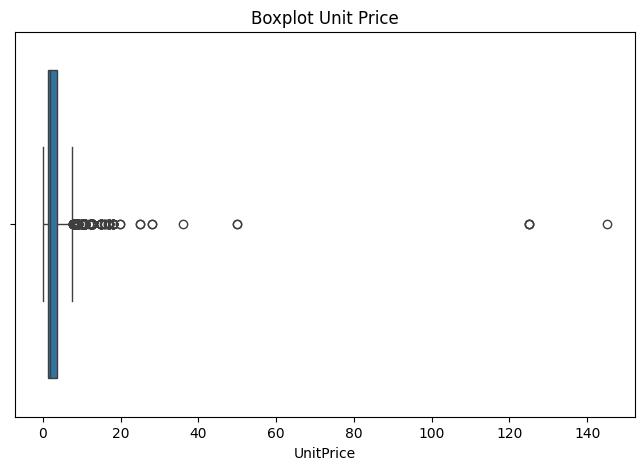

In [ ]:
# Visualisasi outlier
plt.figure(figsize=(8,5))
sns.boxplot(x=df_ecommerce['UnitPrice'])
plt.title('Boxplot Unit Price')
plt.show()

Dari boxplot terlihat terdapat beberapa nilai yang berada jauh di atas distribusi utama data, yang menunjukkan adanya outlier pada harga produk.

# 2. Setelah melakukan feature engineering, Ikuti anjuran berikut :
- Buat 5 pertanyaan analisa
- jawab dengan pendekatan metode data manipulation (sorting, filtering, group by, pivot, melt, crosstab, working with datetime, dsb )sesuaikan dengan keperluan anda
- Buatlah visualisasi grafik supaya mempermudah dalam ekstraksi insight setelah menjawab menggunakan metode data manipulation diatas
- Tulis insight anda

`poin` :
- insight / observation : **10 poin (1 pertanyaan 2 poin)**
- pertanyaan analisis dan jawaban metode data manipulation : **30 poin (1 pertanyaan 7 poin)**
- data visualisasi : **30 poin (1 visualisasi dari 1 pertanyaan 7 poin)**

**1. Negara mana yang memiliki total transaksi tertinggi?**

In [ ]:
# Untuk mencari total price
df_ecommerce['TotalPrice'] = df_ecommerce['Quantity'] * df_ecommerce['UnitPrice']
country_sales = df_ecommerce.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)
country_sales.head(10)

,TotalPrice
Country,
United Kingdom,93011.36
Netherlands,3622.33
Germany,3363.77
EIRE,3156.78
France,2320.55
Sweden,988.74
Australia,937.00
Switzerland,902.52
Portugal,562.90


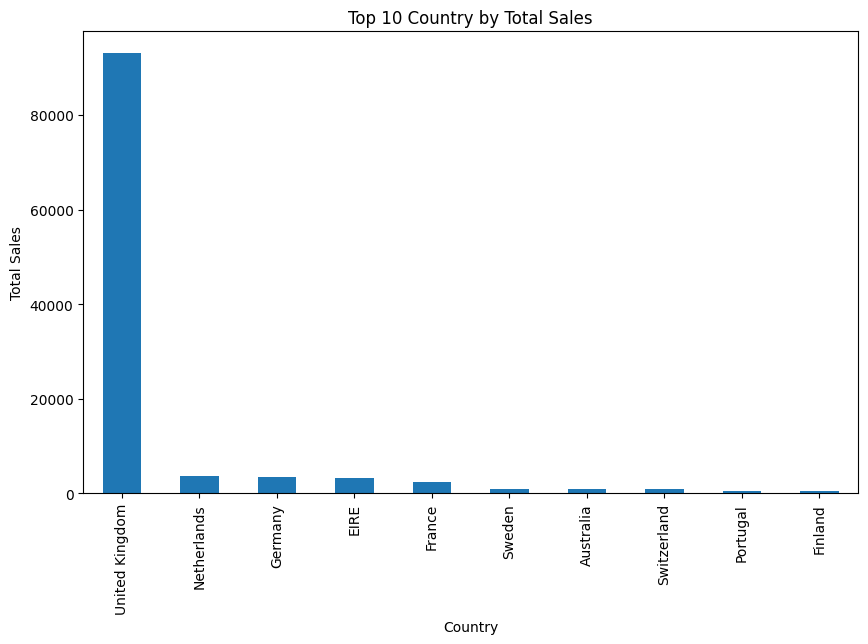

In [ ]:
plt.figure(figsize=(10,6))
country_sales.head(10).plot(kind='bar')
plt.title('Top 10 Country by Total Sales')
plt.ylabel('Total Sales')
plt.xlabel('Country')
plt.show()

Negara dengan total transaksi tertinggi adalah United Kingdom, yang menunjukkan bahwa mayoritas pelanggan berasal dari negara tersebut. Hal ini mengindikasikan bahwa pasar utama perusahaan berada di wilayah tersebut.

**2. Produk apa yang paling sering dibeli pelanggan?**

In [ ]:
top_products = df_ecommerce.groupby('Description')['Quantity'].sum().sort_values(ascending=False)
top_products.head(10)

,Quantity
Description,
WHITE HANGING HEART T-LIGHT HOLDER,1291
CREAM HEART CARD HOLDER,1032
"WRAP, BILLBOARD FONTS DESIGN",825
JUMBO BAG RED RETROSPOT,783
MIRROR MOSAIC T-LIGHT HOLDER,720
ASSORTED COLOURS SILK FAN,648
SWEETHEART BIRD HOUSE,621
JUMBO BAG ALPHABET,608
JUMBO BAG STRAWBERRY,585


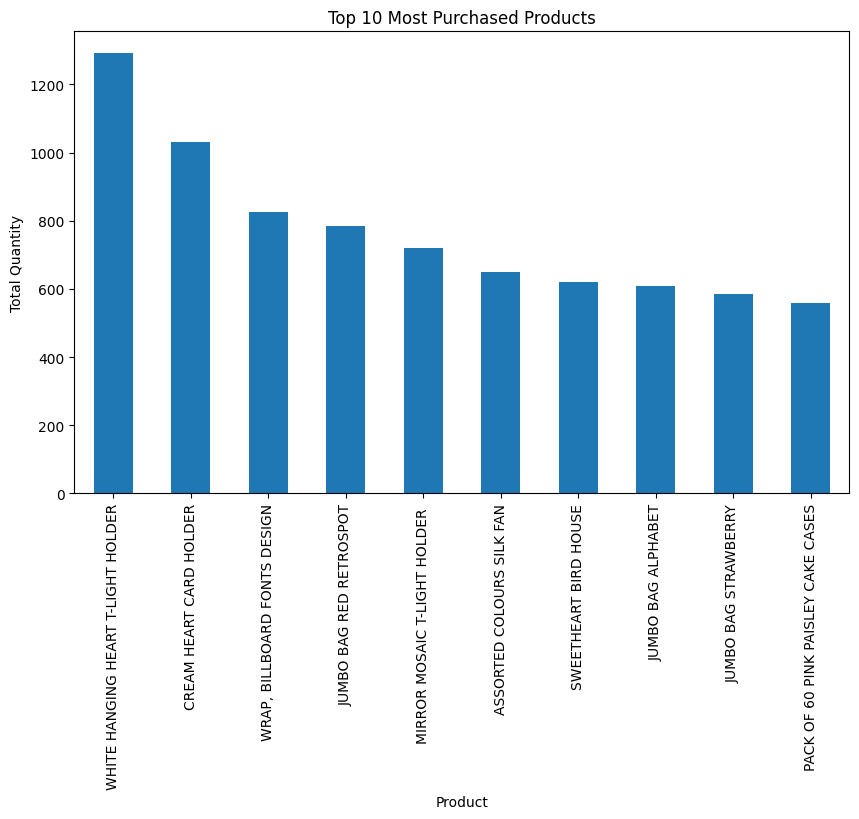

In [ ]:
# Visualisasi
plt.figure(figsize=(10,6))
top_products.head(10).plot(kind='bar')
plt.title('Top 10 Most Purchased Products')
plt.ylabel('Total Quantity')
plt.xlabel('Product')
plt.show()

Produk dengan jumlah pembelian tertinggi menunjukkan bahwa produk tersebut memiliki permintaan pasar yang tinggi. Produk ini dapat menjadi fokus utama dalam strategi pemasaran atau manajemen stok.

**3. Bagaimana tren total penjualan setiap bulan?**

In [ ]:
# Data Manipulation (Working with Datetime + Groupby)
monthly_sales = df_ecommerce.groupby('Month')['TotalPrice'].sum()
monthly_sales # type: ignore

,TotalPrice
Month,
1,6247.52
2,6152.46
3,7162.64
4,6357.63
5,6987.24
6,7203.93
7,7569.27
8,9904.91
9,9761.11


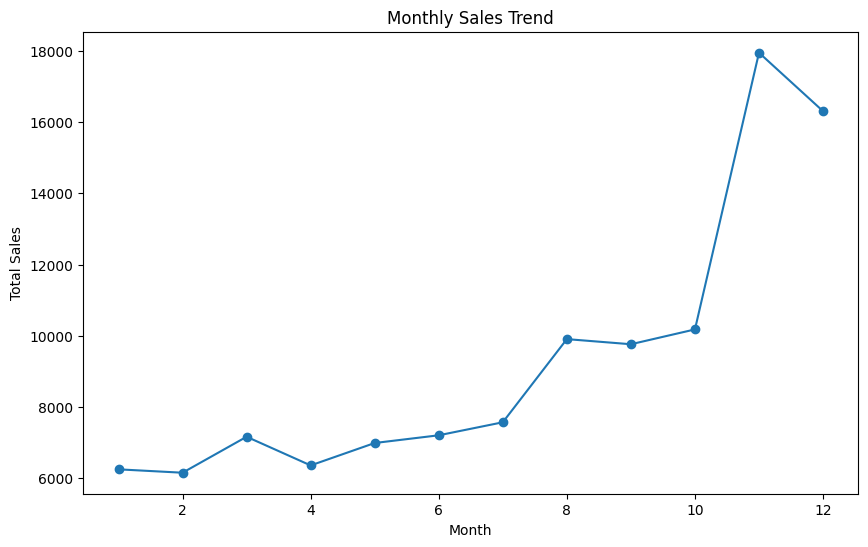

In [ ]:
# visualisasi

plt.figure(figsize=(10,6))
monthly_sales.plot(marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.show()

Tren penjualan menunjukkan fluktuasi pada beberapa bulan tertentu. Jika terjadi lonjakan pada bulan tertentu, hal ini dapat berkaitan dengan musim belanja atau event promosi tertentu.

**4. Jam berapa transaksi paling sering terjadi?**

In [ ]:
hourly_transactions = df_ecommerce.groupby('Hour')['InvoiceNo'].count()
hourly_transactions

,InvoiceNo
Hour,
7,5
8,102
9,263
10,464
11,586
12,902
13,773
14,686
15,562


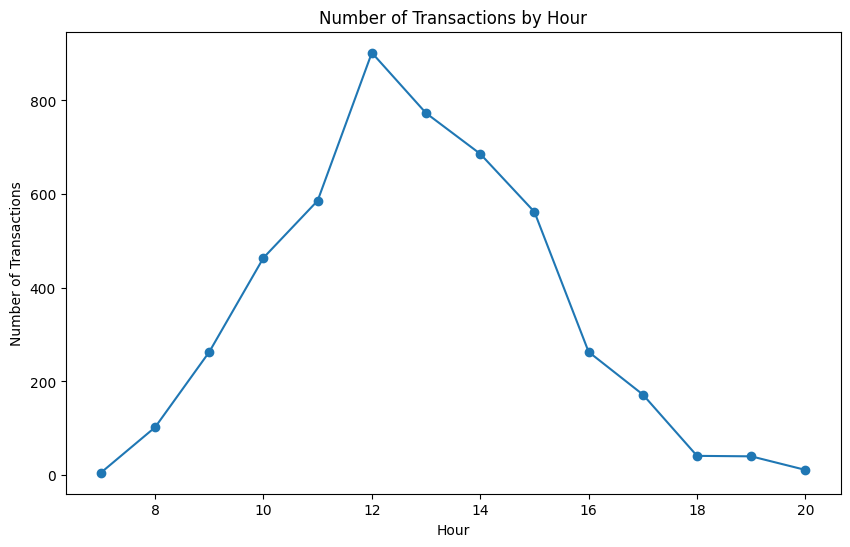

In [ ]:
plt.figure(figsize=(10,6))
hourly_transactions.plot(kind='line', marker='o')
plt.title('Number of Transactions by Hour')
plt.xlabel('Hour')
plt.ylabel('Number of Transactions')
plt.show()

Analisis ini menunjukkan waktu di mana aktivitas transaksi pelanggan paling tinggi. Informasi ini dapat digunakan untuk menentukan waktu terbaik dalam menjalankan promosi atau kampanye pemasaran.

**5. Apakah terdapat hubungan antara jumlah produk yang dibeli dengan total transaksi?**

In [ ]:
df_ecommerce[['Quantity','TotalPrice']].corr()

,Quantity,TotalPrice
Quantity,1.000000,0.788586
TotalPrice,0.788586,1.000000


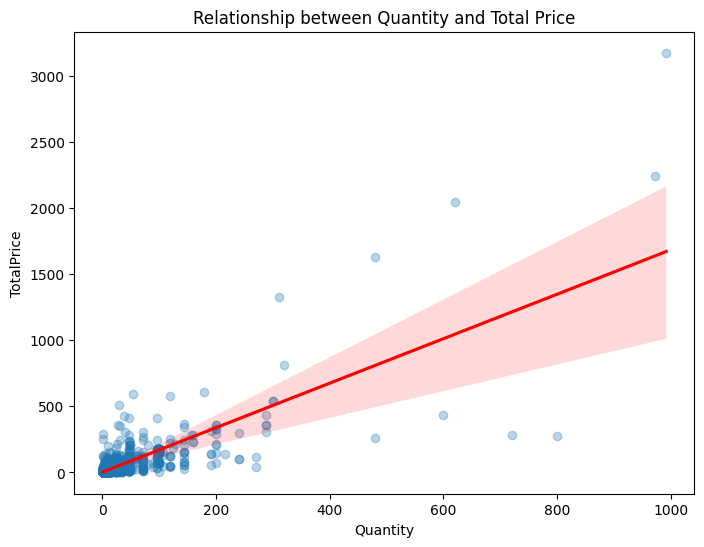

In [ ]:
# Visualisasi
plt.figure(figsize=(8,6))
sns.regplot(x='Quantity', y='TotalPrice', data=df_ecommerce, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Relationship between Quantity and Total Price')
plt.show()

Terdapat hubungan positif antara Quantity dan TotalPrice, yang berarti semakin banyak produk yang dibeli, semakin besar nilai transaksi yang dihasilkan.

**Kesimpulan**

Berdasarkan hasil Exploratory Data Analysis pada dataset ecommerce:

+ United Kingdom merupakan negara dengan kontribusi transaksi terbesar.

+ Beberapa produk memiliki jumlah pembelian yang jauh lebih tinggi dibanding produk lainnya, yang menunjukkan permintaan tinggi.

+ Tren penjualan bulanan menunjukkan adanya fluktuasi yang kemungkinan dipengaruhi oleh musim belanja atau promosi tertentu.

+ Beberapa negara memiliki nilai transaksi rata-rata lebih besar, menunjukkan daya beli pelanggan yang lebih tinggi.

+ Terdapat hubungan positif antara jumlah produk yang dibeli dengan total nilai transaksi.

Insight ini dapat membantu perusahaan dalam strategi pemasaran, manajemen stok, dan pengembangan pasar.

## 3. Lakukan analisa multivariate pada kolom numerikal berupa :
- Correlation Heatmap + insight / observation **(10 poin)**

In [ ]:
# Memilih kolom numerikal

numerical_cols = ['Quantity','UnitPrice','TotalPrice']

corr_matrix = df_ecommerce[numerical_cols].corr()
corr_matrix

,Quantity,UnitPrice,TotalPrice
Quantity,1.000000,-0.083283,0.788586
UnitPrice,-0.083283,1.000000,0.091612
TotalPrice,0.788586,0.091612,1.000000


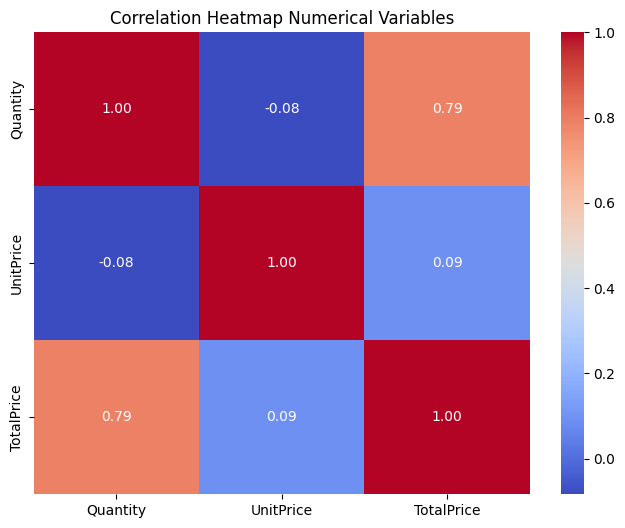

In [ ]:
# Membuat heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap Numerical Variables')
plt.show()

Berdasarkan correlation heatmap, terlihat bahwa terdapat korelasi positif yang kuat antara Quantity dan TotalPrice. Hal ini menunjukkan bahwa semakin banyak jumlah produk yang dibeli, maka semakin besar total nilai transaksi yang dihasilkan.

Sementara itu, korelasi antara UnitPrice dan Quantity cenderung rendah, yang menunjukkan bahwa harga produk tidak terlalu mempengaruhi jumlah produk yang dibeli oleh pelanggan.

Selain itu, terdapat korelasi positif antara UnitPrice dan TotalPrice, yang menunjukkan bahwa produk dengan harga lebih tinggi dapat menghasilkan nilai transaksi yang lebih besar.